# Pretrain A/B/C **품질** 비교 (RMSE + 슬롯 분포 검증)

`compare_pretrain_ab.py` 노트북은 *속도/리소스* 만 비교합니다. 이 노트북은 그 자매편으로 **모델 정확도** (downstream RMSE) 를 비교하고, 동시에 "진짜로 augmentation 이 weighted 로 바뀌었는지" 를 슬롯 빈도 분포로 검증합니다.

비교 대상 (전부 ESOL 동일 시드/하이퍼파라미터, augmentation 정책만 다름):

| 측면 | aug_1 / aug_2 | views_fn | 슬롯 |
|---|---|---|---|
| **A** baseline | `MMFFrandom` / `MMFFrandom` | `RandomView` (원본 PyG 경로) | 사전 추출된 2개 균등 |
| **B** top1+identity | `MMFFweighted_top1` / `None` | view1=`WeightedMMFFView`(top1), view2=identity | QDF 가중치로 argmax 슬롯; 두 번째 뷰는 원본 `pos` |
| **C** weighted pair | `SIDE_C_AUG_2` (예: `top12`) | `WeightedMMFFView` 등 | **MMFF1..4** + `.pt` 가중치; C는 1등 vs 2등 슬롯 등 페어 설정 가능 |

각 셀은 독립적으로 다시 돌릴 수 있으며, 셀 1 의 `QUALITY_SMOKE`·`P_EPOCH`·`F_EPOCH`·`BATCH_SIZE` 등으로 빠른 스모크 ↔ 본격 실험을 오갑니다.

프리트레인 체크포인트는 각 측면별 **별도 폴더** (`./models/quality_<ts>/A`, `B`, `C`) 에 저장됩니다. PNG / JSON 은 `figs/pretrain_quality_<MMDD_HHMM>/` 에 들어갑니다.

In [3]:
# --- 1. Setup -----------------------
# ----------------------------------------
import os, sys, json, time, gc
from datetime import datetime
from pathlib import Path


NB_DIR = Path.cwd()
# 노트북 launcher 의 CWD 가 어디든 repo root 로 정렬.
REPO_ROOT = NB_DIR
for _p in [NB_DIR, *NB_DIR.parents]:
    if (_p / 'dig').is_dir() and (_p / 'examples').is_dir():
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)
for p in [REPO_ROOT, REPO_ROOT / 'examples' / 'sslgraph' / 'bench']:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
import torch
from dig.sslgraph.utils.device import pick_torch_device
import pretrain_quality_core as q

FIG_TS = datetime.now().strftime('%m%d_%H%M')
RUN_DIR = REPO_ROOT / 'examples' / 'sslgraph' / 'bench' / 'figs' / f'pretrain_quality_{FIG_TS}'
RUN_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ROOT = REPO_ROOT / 'models' / f'quality_{FIG_TS}'
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = pick_torch_device()
print('device:', DEVICE)
print('run dir:', RUN_DIR)
print('models  :', MODEL_ROOT)

# ===== 사용자가 자주 만지는 노브 =================================================
DATASET        = 'esol'      # pretrain + finetune 공통
BATCH_SIZE     = 400
P_EPOCH        = 50          # 본격 비교. 스모크는 아래 QUALITY_SMOKE 블록에서 덮어씀.
F_EPOCH        = 100         # 본격 finetune 기본값(스모크에서 18로 축소).
FINETUNE_BATCH = 128         # finetune.ipynb 기본 32 → 128 (XPU 점유율 ↑, ~2-3× 빠름)
N_TIMES        = 3           # 본격 비교에서 분산 줄이려면 ≥3.
N_FOLDS        = 5           # 본격 비교(5-fold). 스모크에서 2로 축소.
WEIGHT_KT     = 0.3       # softmax 온도. homolumo 는 rotamer 간 차이가 작아 0.3 권장(atomization 0.5).
WEIGHT_MODE   = 'auto'    # 'explicit' / 'energy' / 'auto'
WEIGHT_NORM   = 'zscore'  # 'none' / 'zscore' / 'rank'. QDF 출력 차이가 작으므로 zscore 권장.
WEIGHT_SOURCE = 'qdf'     # 'qdf' (CSV 기반) or 'boltzmann' (에너지 기반)
QDF_PROPERTY  = 'homolumo'     # 'homolumo'    (QM9under7atoms dim=200 op=mean, ESOL은 OOD라 zscore 필수)
                               # 'atomization' (대안: QM9under14atoms dim=250 op=sum, conformer 민감)
QDF_CHECKPOINT = None     # None = qdf_mmff_predict.py 의 preset 사용
                          # 다른 ckpt 시도 시 절대/상대 경로 입력
SCORE_EXPR    = None      # None = property 의 default
                          #   atomization → '-energy' (더 음수 = 더 안정 = 더 높은 점수)
                          #   homolumo    → 'gap' (= LUMO−HOMO, 갭 클수록 높은 점수)
WEIGHT_FALLBACK = 'boltzmann'  # QDF가 cover 못한 분자 처리. 'boltzmann' 권장.
                               # 'boltzmann' = MMFF 에너지 기반 Boltzmann (커버리지 100%)
                               # 'uniform'   = 0.25 균등 (= side A 와 동일)
                               # 'skip'      = .pt 에 빠뜨림 → view 가 균등 fallback
QDF_PRED_CSV = REPO_ROOT / 'dataset' / f'esol_qdf_mmff_preds_{QDF_PROPERTY}.csv'
WEIGHTS_PT   = REPO_ROOT / 'dataset' / f'esol_mmff_weights_qdf_{QDF_PROPERTY}.pt'
DIST_N_CALLS = 50         # 슬롯 분포 검증용 view 호출 횟수
DIST_BATCH   = 256

SIDES = ('A', 'B', 'C')
QUALITY_SMOKE = True   # True: 짧은 epoch/fold + SchNet (테스트용). False: 아래 본값 사용.
colors = {'A': '#7f7f7f', 'B': '#2ca02c', 'C': '#d62728'}
labels = {
    'A': 'A baseline (RandomView)',
    'B': 'B top1 + identity',
    'C': 'C weighted (top1 vs top2)',
}

# --- epoch wall-time (DataLoader + mixed-precision forward) -----------------
# ESOL 은 epoch 당 배치 수가 적어서(≈3 @400) GPU/XPU 커널이 병목인 경우가 많습니다.
PRETRAIN_NUM_WORKERS = 4   # Linux/WSL: 4~8 권장. Windows+RDKit 에서 worker 오류 시 0 유지.
PRETRAIN_PIN_MEMORY = False # 호스트→디바이스 복사 힌트; 문제 시 False.
PRETRAIN_AMP = False        # CUDA/XPU 에서 encoder+proj forward autocast (미지원 시 자동 무시).

# --- 진단 순서 (A → C → B): cutoff, side-C view-2, 백본 --------------------
# (A) SchNet cutoff 축소: 국소 RBF가 conformers 차이에 더 민감해지도록.
PRETRAIN_CUTOFF = 3.0
# (C) Side C 의 view 페어 선택 방식.
#   "top1"         — 양쪽 view 모두 1등(argmax) 슬롯만. 2등은 계산도 안 함.
#                    positive pair = 같은 좌표 두 번. augmentation=identity
#                    ablation.
#   "top12"        — (1등, 2등) 결정적 짝. 두 view 가 같은 그래프에서 항상
#                    가장 가중치 높은 / 두 번째 슬롯을 가져옵니다.
#   "noise"        — view1=MMFFweighted, view2=NodeTranslation(noise) (약함)
#   "MMFFweighted" — 레거시(양쪽 모두 가중 i.i.d. 샘플)
SIDE_C_AUG_2 = "top12"   # Side C: 1등 vs 2등 슬롯 (결정적). 스모크/본실험 공통 권장.
# pretrain 백본; finetune 은 summary 의 pretrain_encoder / cutoff 를 따름.
PRETRAIN_ENCODER = "spherenet"  # 본실험: angle/torsion. QUALITY_SMOKE 시 아래에서 schnet 으로 덮어씀.

if QUALITY_SMOKE:
    # 목표: XPU 기준 총 ~5분.
    #   pretrain  : 5 ep × 3 sides ≈ 1분
    #   slot dist : 20 calls × 3 sides ≈ 30s
    #   finetune  : 18 ep × 2 fold × 3 sides × 2.6s ≈ 4.5분
    P_EPOCH, F_EPOCH = 5, 18
    N_FOLDS, N_TIMES = 2, 1
    DIST_N_CALLS, DIST_BATCH = 20, 128
    PRETRAIN_ENCODER = "gin"

os.environ['DATALOADER_NUM_WORKERS'] = str(int(PRETRAIN_NUM_WORKERS))
if PRETRAIN_PIN_MEMORY:
    os.environ['PIN_MEMORY'] = '1'
else:
    os.environ.pop('PIN_MEMORY', None)
# ============================================================================

print({
    'DATASET': DATASET, 'BATCH_SIZE': BATCH_SIZE,
    'SIDES': SIDES, 'QUALITY_SMOKE': QUALITY_SMOKE,
    'P_EPOCH': P_EPOCH, 'F_EPOCH': F_EPOCH,
    'N_TIMES': N_TIMES, 'N_FOLDS': N_FOLDS,
    'WEIGHT_KT': WEIGHT_KT, 'WEIGHT_MODE': WEIGHT_MODE,
    'WEIGHT_NORM': WEIGHT_NORM, 'WEIGHT_SOURCE': WEIGHT_SOURCE,
    'QDF_PROPERTY': QDF_PROPERTY, 'QDF_PRED_CSV': QDF_PRED_CSV.name,
    'WEIGHTS_PT': WEIGHTS_PT.name,
    'DIST_N_CALLS': DIST_N_CALLS, 'DIST_BATCH': DIST_BATCH,
    'PRETRAIN_NUM_WORKERS': PRETRAIN_NUM_WORKERS,
    'PRETRAIN_PIN_MEMORY': PRETRAIN_PIN_MEMORY,
    'PRETRAIN_AMP': PRETRAIN_AMP,
    'PRETRAIN_CUTOFF': PRETRAIN_CUTOFF,
    'SIDE_C_AUG_2': SIDE_C_AUG_2,
    'PRETRAIN_ENCODER': PRETRAIN_ENCODER,
})

device: cpu
run dir: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0116
models  : /home/ubuntu/3DGCL/models/quality_0514_0116
{'DATASET': 'esol', 'BATCH_SIZE': 400, 'SIDES': ('A', 'B', 'C'), 'QUALITY_SMOKE': True, 'P_EPOCH': 5, 'F_EPOCH': 18, 'N_TIMES': 1, 'N_FOLDS': 2, 'WEIGHT_KT': 0.3, 'WEIGHT_MODE': 'auto', 'WEIGHT_NORM': 'zscore', 'WEIGHT_SOURCE': 'qdf', 'QDF_PROPERTY': 'homolumo', 'QDF_PRED_CSV': 'esol_qdf_mmff_preds_homolumo.csv', 'WEIGHTS_PT': 'esol_mmff_weights_qdf_homolumo.pt', 'DIST_N_CALLS': 20, 'DIST_BATCH': 128, 'PRETRAIN_NUM_WORKERS': 4, 'PRETRAIN_PIN_MEMORY': False, 'PRETRAIN_AMP': False, 'PRETRAIN_CUTOFF': 3.0, 'SIDE_C_AUG_2': 'top12', 'PRETRAIN_ENCODER': 'gin'}


## 1. weights 파일 준비

**B 또는 C** 측면을 돌리려면 `MMFF_WEIGHTS_PATH` (per-graph slot weights `.pt`) 가 필요합니다.

| `WEIGHT_SOURCE` | `QDF_PROPERTY` | CSV columns | 의미 | 권장 사용처 |
|---|---|---|---|---|
| `qdf` | `atomization` | `smiles,slot,energy` | softmax(z-score(−energy)/kT) — **conformer 별로 큰 차이**, ESOL/큰 분자에 강함 | **현재 기본값** |
| `qdf` | `homolumo` | `smiles,slot,homo,lumo` | softmax(z-score((LUMO−HOMO))/kT) 기본 `gap`; rotamer 간 ~meV | 비교/회귀 분석용 |
| `boltzmann` | — | (CSV 없이 MMFF energy) | softmax(-(E_k - E_min)/kT) | QDF 모델이 사용 불가일 때 |

체크포인트 선택은 `qdf_mmff_predict.py` 가 `--qdf-property` 의 **preset** 으로 자동 결정합니다.
다른 ckpt 를 시도하려면 setup 셀의 `QDF_CHECKPOINT` 에 경로를 넣으세요.

| `QDF_PROPERTY` | preset checkpoint |
|---|---|
| `atomization` | `output/model--QM9under14atoms_atomizationenergy_eV--6-31G--…--dim250--hidden_HK250--sum--batch_size4--iteration2000` |
| `homolumo`    | `output/model--QM9under7atoms_homolumo_eV--6-31G--…--dim200--hidden_HK200--mean--batch_size8--iteration2000` |

이미 `dataset/esol_mmff_weights_qdf_<property>.pt` 가 있으면 캐시를 씁니다. 다만 **디스크에 저장된 `kT` 가 셀 1 의 `WEIGHT_KT` 와 다르면** (가중치 첨예화 변경 시) 자동으로 `compute_mmff_weights.py` 를 다시 돌려 `.pt` 를 갱신합니다.

In [4]:
# --- 2. Ensure weights .pt --------------------------------------------------
import subprocess

PY = sys.executable

def _run(cmd, **kw):
    print('$', ' '.join(str(c) for c in cmd))
    return subprocess.run([str(c) for c in cmd], check=True, **kw)

_rebuild_weights = not WEIGHTS_PT.is_file()
if WEIGHTS_PT.is_file():
    _w0 = torch.load(WEIGHTS_PT, map_location='cpu', weights_only=False)
    _disk_kt = float(_w0.get('kT', float('nan')))
    _disk_fb = _w0.get('fallback')
    _disk_fb_policy = _disk_fb.get('policy') if isinstance(_disk_fb, dict) else None
    if abs(_disk_kt - float(WEIGHT_KT)) > 1e-6:
        print('[info] on-disk kT', _disk_kt, '!= WEIGHT_KT', WEIGHT_KT,
              '— recomputing .pt so softmax temperature (D) matches setup.')
        _rebuild_weights = True
    elif WEIGHT_SOURCE == 'qdf' and _disk_fb_policy != WEIGHT_FALLBACK:
        print('[info] on-disk fallback', _disk_fb_policy, '!= WEIGHT_FALLBACK',
              WEIGHT_FALLBACK, '— recomputing so QDF-uncovered molecules use the new policy.')
        _rebuild_weights = True
    elif WEIGHT_SOURCE == 'qdf':
        try:
            _want_se = q.desired_qdf_score_expr(QDF_PROPERTY, SCORE_EXPR)
            _disk_se = str(_w0.get('score_expr', ''))
            if _disk_se.replace(' ', '') != _want_se.replace(' ', ''):
                print('[info] on-disk score_expr', repr(_disk_se), '!= desired',
                      repr(_want_se), '— recomputing .pt.')
                _rebuild_weights = True
        except Exception as _e:
            print('[warn] score_expr cache check skipped:', _e)

if _rebuild_weights:
    if WEIGHT_SOURCE == 'qdf':
        if not QDF_PRED_CSV.is_file():
            print(f'[info] running qdf_mmff_predict.py ({QDF_PROPERTY}) — this is slow.')
            pred_cmd = [PY, 'examples/sslgraph/bench/qdf_mmff_predict.py',
                        '--dataset', DATASET,
                        '--qdf-property', QDF_PROPERTY,
                        '--out', QDF_PRED_CSV]
            if QDF_CHECKPOINT:
                pred_cmd += ['--checkpoint', str(QDF_CHECKPOINT)]
            _run(pred_cmd)
        weights_cmd = [PY, 'examples/sslgraph/bench/compute_mmff_weights.py',
                       '--dataset', DATASET, '--source', 'qdf',
                       '--pred-csv', QDF_PRED_CSV,
                       '--kT', WEIGHT_KT,
                       '--normalize', WEIGHT_NORM,
                       '--fallback', WEIGHT_FALLBACK,
                       '--out', WEIGHTS_PT]
        if SCORE_EXPR:
            weights_cmd += ['--score-expr', SCORE_EXPR]
        _run(weights_cmd)
    else:
        _run([PY, 'examples/sslgraph/bench/compute_mmff_weights.py',
              '--dataset', DATASET, '--source', 'boltzmann',
              '--kT', WEIGHT_KT,
              '--out', WEIGHTS_PT])

print('weights file:', WEIGHTS_PT, 'exists=', WEIGHTS_PT.is_file())
if WEIGHTS_PT.is_file():
    meta = torch.load(WEIGHTS_PT, map_location='cpu', weights_only=False)
    print('  meta:', {k: meta.get(k) for k in ('source', 'kT', 'qdf_property',
                                                'score_expr', 'normalize')})
    print('  fallback:', meta.get('fallback'))
    print('  n_smiles in weights file:', len(meta.get('weights', {})))

    # Coverage check vs the actual ESOL dataset. WeightedMMFFView falls back to
    # uniform sampling for SMILES without weights → these molecules behave
    # like side A. If coverage is far below 100%, the A vs C signal is
    # diluted proportionally and small-sample noise can flip the comparison.
    try:
        from dig.threedgraph.dataset import MoleculeNet
        _ds = MoleculeNet(root=str(REPO_ROOT / 'dataset'), name=DATASET)
        _smiles = set(meta.get('weights', {}).keys())
        _n_total = len(_ds)
        _n_cov = sum(1 for d in _ds if getattr(d, 'smiles', None) in _smiles)
        _cov = _n_cov / max(_n_total, 1)
        _fb_meta = meta.get('fallback') or {}
        _fb_pol = _fb_meta.get('policy') if isinstance(_fb_meta, dict) else None
        _n_boltz = int(_fb_meta.get('n_added', 0)) if isinstance(_fb_meta, dict) else 0
        _n_uni = int(_fb_meta.get('n_uniform', 0)) if isinstance(_fb_meta, dict) else 0
        _n_qdf = max(_n_cov - _n_boltz - _n_uni, 0)
        print(f'  coverage: {_n_cov}/{_n_total} ({_cov*100:.1f}%)  '
              f'[QDF~{_n_qdf}, boltzmann_fallback={_n_boltz}, uniform={_n_uni}]')
        if _cov < 0.9:
            print(f'  ⚠ coverage < 90%: 비-가중치 분자가 view 단계에서 uniform 으로 fallback 됩니다. '
                  "WEIGHT_FALLBACK='boltzmann' 으로 다시 빌드하면 P/S/Cl/Br/I 분자도 "
                  'MMFF 에너지 기반 가중치를 받습니다.')
        elif _fb_pol == 'boltzmann' and _n_boltz > 0:
            print(f'  ✓ QDF-uncovered {_n_boltz} 분자는 MMFF 에너지 Boltzmann 으로 채워졌습니다.')
    except Exception as _e:
        print('  (coverage check skipped:', _e, ')')

weights file: /home/ubuntu/3DGCL/dataset/esol_mmff_weights_qdf_homolumo.pt exists= True
  meta: {'source': 'qdf', 'kT': 0.3, 'qdf_property': 'homolumo', 'score_expr': '-(lumo - homo)', 'normalize': 'zscore'}
  fallback: {'policy': 'boltzmann', 'n_added': 392, 'n_uniform': 0, 'n_total': 1128}
  n_smiles in weights file: 1123
  coverage: 916/1128 (81.2%)  [QDF~524, boltzmann_fallback=392, uniform=0]
  ⚠ coverage < 90%: 비-가중치 분자가 view 단계에서 uniform 으로 fallback 됩니다. WEIGHT_FALLBACK='boltzmann' 으로 다시 빌드하면 P/S/Cl/Br/I 분자도 MMFF 에너지 기반 가중치를 받습니다.


## 2. 슬롯 분포 검증 — "진짜 랜덤이 바뀌었나?"

각 측면마다 GraphCL 의 첫 배치에 대해 **라운드를 `DIST_N_CALLS` 번** 반복합니다. 라운드마다 **aug_1(view1)** 과 **aug_2(view2)** 를 각각 한 번 호출하고, 두 뷰에서 나온 MMFF 슬롯 (1..4) 선택을 **하나의 분포로 합산**합니다 (뷰 호출 ≈ `2 × DIST_N_CALLS` × 그래프 수). 반환값·`slot_distribution.json` 에는 `view0`·`view1` 키로 aug1·aug2 **각각**의 `slot_freq`·KL·entropy 가 따로 들어 있습니다. 일치 판정은 `out.pos` 와 `batch.max{k}pos_mmff` 의 정확 비교 (atol=1e-5).

기대값:
* **A**  — `random.sample` 이 `aug_1/aug_2` 초기화 시 미리 고른 **2개 슬롯에만** 표가 몰린다 (≈50:50, 나머지 0).
* **C**  — MMFF1..4 **4개 슬롯 전체** 사용. KL(observed‖uniform) 와 per-graph entropy 가 A 와 다르다.

In [5]:
# --- 3. Slot distribution check --------------------------------------------
dist_results = {}
for side in SIDES:
    kw = dict(
        dataset=DATASET, batch_size=DIST_BATCH,
        n_calls=DIST_N_CALLS, device=DEVICE,
        weight_kT=WEIGHT_KT, weight_mode=WEIGHT_MODE,
        weight_norm=WEIGHT_NORM,
        p_pretrain_amp=PRETRAIN_AMP,
        encoder=PRETRAIN_ENCODER,
        cutoff=PRETRAIN_CUTOFF,
        side_c_aug_2=SIDE_C_AUG_2,
    )
    if side in ('B', 'C'):
        kw['weights_path'] = WEIGHTS_PT
    t0 = time.perf_counter()
    res = q.measure_slot_distribution(side, **kw)
    res['elapsed_s'] = time.perf_counter() - t0
    dist_results[side] = res
    v0, v1 = res['view_classes']
    print(f"[{side}] {res['view_class']}")
    print(f"  pooled  slots={res['slot_freq']} "
          f"KL={res['kl_to_uniform_bits']:.3f}b  H̄={res['per_graph_entropy_bits_mean']:.3f}b")
    print(f"  view0 ({v0}) slots={res['view0']['slot_freq']} "
          f"KL={res['view0']['kl_to_uniform_bits']:.3f}b  H̄={res['view0']['per_graph_entropy_bits_mean']:.3f}b")
    print(f"  view1 ({v1}) slots={res['view1']['slot_freq']} "
          f"KL={res['view1']['kl_to_uniform_bits']:.3f}b  H̄={res['view1']['per_graph_entropy_bits_mean']:.3f}b")

with open(RUN_DIR / 'slot_distribution.json', 'w', encoding='utf-8') as f:
    json.dump(dist_results, f, indent=2)
print('saved:', RUN_DIR / 'slot_distribution.json')

[A] view=RandomView slots=[0.0, 0.50234375, 0.0, 0.49765625] KL(uni)=1.000b  H̄/graph=0.960b
[B] view=WeightedMMFFView slots=[0.3046875, 0.1328125, 0.1875, 0.375] KL(uni)=0.107b  H̄/graph=-0.000b
[C] view=WeightedMMFFView slots=[0.3046875, 0.1328125, 0.1875, 0.375] KL(uni)=0.107b  H̄/graph=-0.000b
saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0116/slot_distribution.json


saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0116/slot_distribution_0514_0116.png


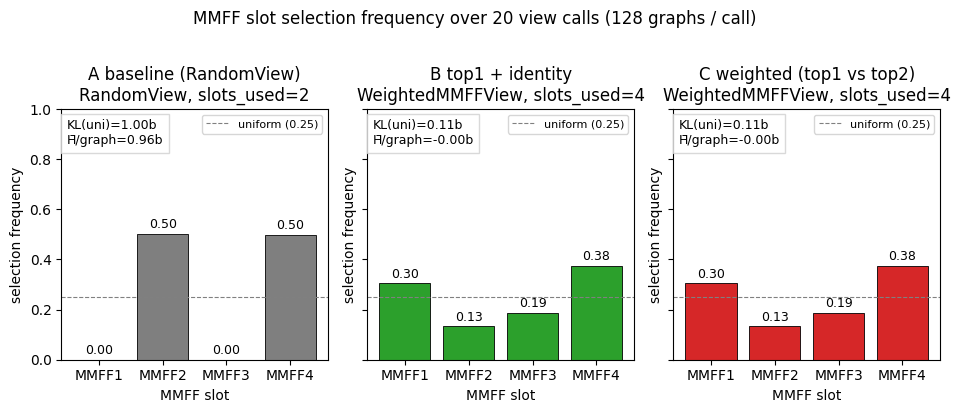

In [6]:
# --- 4. Slot distribution plot ---------------------------------------------
_n = len(SIDES)
fig, axes = plt.subplots(1, _n, figsize=(3.2 * _n, 4.0), sharey=True)
if _n == 1:
    axes = [axes]
for ax, side in zip(axes, SIDES):
    r = dist_results[side]
    bars = ax.bar(['MMFF1', 'MMFF2', 'MMFF3', 'MMFF4'], r['slot_freq'],
                  color=colors[side], edgecolor='black', linewidth=0.6)
    ax.axhline(0.25, color='gray', linestyle='--', linewidth=0.8,
               label='uniform (0.25)')
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{labels[side]}\n{r['view_class']}, slots_used={r['n_slots_used']}")
    ax.set_xlabel('MMFF slot')
    ax.set_ylabel('selection frequency')
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)
    ax.text(0.02, 0.96,
            f"KL(uni)={r['kl_to_uniform_bits']:.2f}b\nH̄/graph={r['per_graph_entropy_bits_mean']:.2f}b",
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle(
    f'MMFF slot frequency (aug1+aug2 pooled; {DIST_N_CALLS} rounds, '
    f'{DIST_BATCH} graphs per view)', y=1.02, fontsize=12)
plt.tight_layout()
out = RUN_DIR / f'slot_distribution_{FIG_TS}.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print('saved:', out)
plt.show()

## 3. 전체 Pretrain (A / B / C)

동일한 시드/하이퍼파라미터로 GraphCL 프리트레인을 **세** 번 돌립니다 (각 측면은 별도 폴더). 각 epoch loss 를 캡처해 곡선으로 그립니다.

In [7]:
# --- 5. Run full pretrain for each side -------------------------------------
pre_results = {}
for side in SIDES:
    root = MODEL_ROOT / side
    root.mkdir(parents=True, exist_ok=True)
    kw = dict(
        dataset=DATASET, batch_size=BATCH_SIZE,
        p_epoch=P_EPOCH, model_root=root, device=DEVICE,
        weight_kT=WEIGHT_KT, weight_mode=WEIGHT_MODE,
        weight_norm=WEIGHT_NORM,
        p_pretrain_amp=PRETRAIN_AMP,
        encoder=PRETRAIN_ENCODER,
        cutoff=PRETRAIN_CUTOFF,
        side_c_aug_2=SIDE_C_AUG_2,
    )
    if side in ('B', 'C'):
        kw['weights_path'] = WEIGHTS_PT
    print(f'\n===== pretrain side {side} =====')
    res = q.run_pretrain_side(side, **kw)
    pre_results[side] = res
    print(f"  view={res['view_classes']} wall={res['wall_s']:.1f}s")
    print(f"  best_ckpt={res['best_ckpt']}")
    if res['losses_per_epoch']:
        print(f"  losses: first={res['losses_per_epoch'][0]:.3f}  last={res['losses_per_epoch'][-1]:.3f}")
    gc.collect()
    if hasattr(torch, 'xpu'):
        try: torch.xpu.empty_cache()
        except Exception: pass

with open(RUN_DIR / 'pretrain_summary.json', 'w', encoding='utf-8') as f:
    json.dump(pre_results, f, indent=2, default=str)
print('\nsaved:', RUN_DIR / 'pretrain_summary.json')


===== pretrain side A =====


Pretraining: epoch 1:   0%|          | 0/5 [00:00<?, ?it/s]

/home/ubuntu/3DGCL/models/quality_0514_0116/A/encoder-gin_pretrain-esol_batch-400_proj-spherenet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0


Pretraining: epoch 5: 100%|██████████| 5/5 [00:08<00:00,  1.69s/it, loss=9.2670] 


  view=['RandomView', 'RandomView'] wall=8.9s
  best_ckpt=/home/ubuntu/3DGCL/models/quality_0514_0116/A/encoder-gin_pretrain-esol_batch-400_proj-spherenet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0/enc_best_epoch-5_loss-9.267.pkl
  losses: first=12.153  last=9.267

===== pretrain side B =====


...

  view=['WeightedMMFFView', 'function'] wall=2.2s
  best_ckpt=/home/ubuntu/3DGCL/models/quality_0514_0116/B/encoder-gin_pretrain-esol_batch-400_proj-spherenet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFweighted_top1_aug_2-None_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0/enc_best_epoch-5_loss-9.267.pkl
  losses: first=12.153  last=9.267

===== pretrain side C =====


Pretraining: epoch 1:   0%|          | 0/5 [00:00<?, ?it/s]

/home/ubuntu/3DGCL/models/quality_0514_0116/C/encoder-gin_pretrain-esol_batch-400_proj-spherenet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFweighted_top1_aug_2-MMFFweighted_top2_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0


Pretraining: epoch 5: 100%|██████████| 5/5 [00:01<00:00,  2.91it/s, loss=9.2670] 


  view=['WeightedMMFFView', 'WeightedMMFFView'] wall=2.3s
  best_ckpt=/home/ubuntu/3DGCL/models/quality_0514_0116/C/encoder-gin_pretrain-esol_batch-400_proj-spherenet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFweighted_top1_aug_2-MMFFweighted_top2_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0/enc_best_epoch-5_loss-9.267.pkl
  losses: first=12.153  last=9.267

saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0116/pretrain_summary.json


saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0116/pretrain_loss_0514_0116.png


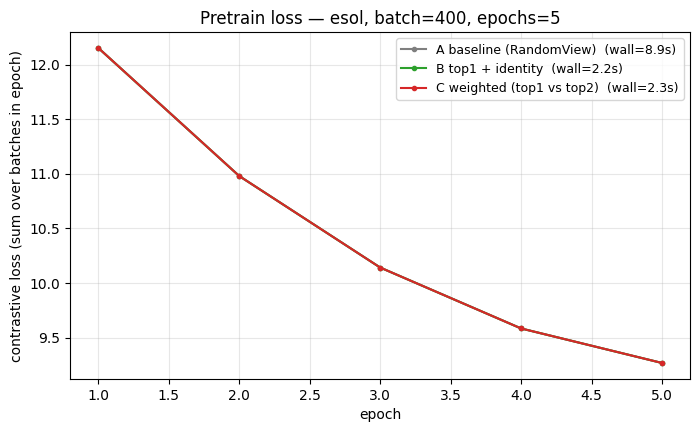

In [8]:
# --- 6. Loss curves ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))
for side in SIDES:
    r = pre_results.get(side)
    if not r or not r['losses_per_epoch']:
        continue
    ys = r['losses_per_epoch']
    ax.plot(range(1, len(ys) + 1), ys, marker='o', markersize=3,
            color=colors[side], label=f"{labels[side]}  (wall={r['wall_s']:.1f}s)")
ax.set_xlabel('epoch')
ax.set_ylabel('contrastive loss (sum over batches in epoch)')
ax.set_title(f'Pretrain loss — {DATASET}, batch={BATCH_SIZE}, epochs={P_EPOCH}')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)
out = RUN_DIR / f'pretrain_loss_{FIG_TS}.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print('saved:', out)
plt.show()

## 3.5 분자별 MMFF 슬롯 가중치 보기

`WEIGHTS_PT` (예: `dataset/esol_mmff_weights_qdf.pt`) 를 사람이 읽을 수 있는 CSV 로 풀고, 가장 한쪽으로 \"치우친\" (uniform 에서 가장 먼) 분자 상위 10개와 가장 균등한 10개를 표로 보여줍니다.

CLI 로도 가능합니다 (`examples/sslgraph/bench/dump_mmff_weights.py`)::

```bash
python examples/sslgraph/bench/dump_mmff_weights.py \
    --in dataset/esol_mmff_weights_qdf.pt \
    --out dataset/esol_mmff_weights_qdf.csv \
    --sort-by top_minus_uniform
```

In [9]:
# --- 6.5 Per-molecule MMFF slot weight table ------------------------------
import pandas as pd
from IPython.display import display

csv_path = WEIGHTS_PT.with_suffix('.csv')
if not csv_path.is_file() and WEIGHTS_PT.is_file():
    _run([PY, 'examples/sslgraph/bench/dump_mmff_weights.py',
          '--in', WEIGHTS_PT, '--out', csv_path,
          '--sort-by', 'top_minus_uniform'])

if csv_path.is_file():
    df_w = pd.read_csv(csv_path)
    print(f'{csv_path}  ({len(df_w)} 분자)')
    # uniform 으로부터 가장 멀리 떨어진 (= 한 슬롯에 가장 표가 몰리는) 상위 10개
    print('\n[top-skewed] uniform 에서 멀리 떨어진 분자 상위 10개')
    display(df_w.head(10)[['smiles', 'w1', 'w2', 'w3', 'w4', 'top_slot', 'top_minus_uniform', 'entropy_bits']])
    # 가장 균등한 (entropy 가 log2(4)=2 에 가까운) 분자 10개
    print('\n[most-uniform] 가중치가 가장 평평한 분자 10개')
    display(df_w.nlargest(10, 'entropy_bits')[['smiles', 'w1', 'w2', 'w3', 'w4', 'top_slot', 'top_minus_uniform', 'entropy_bits']])
    print('\n전체 분포 요약')
    display(df_w[['w1', 'w2', 'w3', 'w4', 'entropy_bits', 'top_minus_uniform']].describe().T)
else:
    print(f'(skip) {WEIGHTS_PT} 또는 {csv_path} 가 없어 표시할 가중치가 없습니다.')

/home/ubuntu/3DGCL/dataset/esol_mmff_weights_qdf_homolumo.csv  (1123 분자)

[top-skewed] uniform 에서 멀리 떨어진 분자 상위 10개


,smiles,w1,w2,w3,w4,top_slot,top_minus_uniform,entropy_bits
0,ClC1C(Cl)C(Cl)C(Cl)C(Cl)C1Cl,0.0,0.0,0.0,1.0,4,0.75,0.000000
1,CC2Nc1cc(Cl)c(cc1C(=O)N2c3ccccc3C)S(N)(=O)=O,0.0,0.0,0.0,1.0,4,0.75,0.000000
2,ClC1=C(Cl)C2(Cl)C3C4CC(C=C4)C3C1(Cl)C2(Cl)Cl,0.0,0.0,0.0,1.0,4,0.75,-0.000000
3,CCc1cccc(C)c1N(C(C)COC)C(=O)CCl,0.0,0.0,0.0,1.0,4,0.75,-0.000000
4,Oc1cc(Cl)cc(Cl)c1Cl,0.0,0.0,0.0,1.0,4,0.75,0.000004
5,CCC2NC(=O)c1cc(c(Cl)cc1N2)S(N)(=O)=O,0.0,0.0,0.0,1.0,4,0.75,0.000002
6,Oc1ccccc1Cl,0.0,0.0,0.0,1.0,4,0.75,0.000008
7,CC(C)NC(=O)N1CC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2,0.0,0.0,0.0,1.0,4,0.75,-0.000000
8,NS(=O)(=O)c2cc1c(N=CNS1(=O)=O)cc2Cl,0.0,0.0,0.0,1.0,4,0.75,0.000004
9,CCOC(=O)N(C)C(=O)CSP(=S)(OCC)OCC,0.0,0.0,0.0,1.0,4,0.75,0.000002



[most-uniform] 가중치가 가장 평평한 분자 10개


,smiles,w1,w2,w3,w4,top_slot,top_minus_uniform,entropy_bits
948,ClC(Cl)(Cl)N(=O)=O,0.249959,0.249971,0.250035,0.250035,3,0.000035,2.0
949,OC(c1ccc(Cl)cc1)(c2ccc(Cl)cc2)C(Cl)(Cl)Cl,0.249990,0.250003,0.250003,0.250003,2,0.000003,2.0
950,CSc1nnc(c(=O)n1N)C(C)(C)C,0.249995,0.250002,0.250002,0.250002,2,0.000002,2.0
951,Clc2c(Cl)c(Cl)c(c1ccccc1)c(Cl)c2Cl,0.249995,0.250002,0.250002,0.250002,2,0.000002,2.0
952,Nc2cnn(c1ccccc1)c(=O)c2Cl,0.249995,0.250002,0.250002,0.250002,2,0.000002,2.0
953,Clc1ccc(cc1)c2c(Cl)cccc2Cl,0.249998,0.250001,0.250001,0.250001,2,0.000001,2.0
954,Clc1cccc(Cl)c1c2c(Cl)cccc2Cl,0.249998,0.250001,0.250001,0.250001,2,0.000001,2.0
955,Clc1ccc(c(Cl)c1Cl)c2c(Cl)cc(Cl)c(Cl)c2Cl,0.249998,0.250001,0.250001,0.250001,2,0.000001,2.0
956,c1ccsc1,0.250000,0.250000,0.250000,0.250000,1,0.000000,2.0
957,c2ccc1scnc1c2,0.250000,0.250000,0.250000,0.250000,1,0.000000,2.0



전체 분포 요약


,count,mean,std,min,25%,50%,75%,max
w1,1123.0,0.177793,0.286673,0.000000,0.000154,0.006862,0.250000,0.998560
w2,1123.0,0.200494,0.293124,0.000000,0.000510,0.033870,0.250000,0.998605
w3,1123.0,0.235050,0.301217,0.000000,0.001653,0.118346,0.297763,0.998587
w4,1123.0,0.386663,0.374075,0.000082,0.011113,0.250000,0.782973,1.000000
entropy_bits,1123.0,0.826480,0.689685,-0.000000,0.170278,0.729526,1.273457,2.000000
top_minus_uniform,1123.0,0.477914,0.272146,0.000000,0.275456,0.576546,0.727863,0.750000


## 4. Finetune RMSE 비교 (downstream 정확도)

각 측면의 best 체크포인트를 SchNet 인코더에 로드해 ESOL 회귀로 finetune (3-fold scaffold split). 평균 test RMSE ± SD 를 보고합니다.

In [10]:
# --- 7. Finetune each checkpoint -------------------------------------------
# 주의: side 1개당 ESOL(1128분자) × 3-fold × F_EPOCH=30 ≈ 3~4분 (XPU Arc 140V 기준).
# SIDES 개수만큼 곱하면 됩니다. 빠르게 보고 싶으면 cell 1 의 F_EPOCH / QUALITY_SMOKE 를 조정한 뒤
# 이 셀만 재실행하면 됩니다.
# 부분 결과는 **side 가 끝날 때마다 즉시** ``finetune_summary.json`` 으로 저장됩니다.
# 따라서 도중에 Ctrl+C 를 눌러도 직전까지 끝난 측면의 RMSE 는 사라지지 않습니다.
# FINETUNE_BATCH 는 cell 1 의 노브를 사용 (기본 128, finetune.ipynb 기본 32 대비 ~2-3×).

# dig/sslgraph/evaluation/finetune.py 의 k_scaffold 가 ESOL 처럼 작은 데이터셋에서
# 더 견고하게 split 을 잡도록 수정됨 (seed perturbation 폭 확장). 셀만 재실행해도
# 새 코드가 반영되도록 명시적으로 reload — kernel restart 불필요.
import importlib
import dig.sslgraph.evaluation.finetune as _ft_mod
importlib.reload(_ft_mod)
import dig.sslgraph.evaluation as _ev_mod
importlib.reload(_ev_mod)
importlib.reload(q)  # pretrain_quality_core 도 새 Finetune 을 참조하도록

summary_path = RUN_DIR / 'finetune_summary.json'
if summary_path.is_file():
    try:
        fine_results = json.loads(summary_path.read_text(encoding='utf-8'))
        print(f'[resume] {summary_path} 에서 {sorted(fine_results.keys())} 측면 결과 발견 — 건너뜁니다.')
    except Exception:
        fine_results = {}
else:
    fine_results = {}

est_per_side_s = max(F_EPOCH, 1) * N_FOLDS * N_TIMES * 2.6  # 대략 XPU 기준
_n_sides = len(SIDES)
print(f'[plan] f_epoch={F_EPOCH} × n_folds={N_FOLDS} × n_times={N_TIMES} '
      f'~ side 1개당 ≈ {est_per_side_s:.0f}s ({est_per_side_s/60:.1f}분), '
      f'{_n_sides} sides ≈ {est_per_side_s*_n_sides/60:.1f}분')

try:
    for side in SIDES:
        if side in fine_results and fine_results[side].get('rmse_mean') is not None:
            r = fine_results[side]
            print(f'\n===== finetune side {side} (cached) =====')
            print(f"  RMSE = {r['rmse_mean']:.4f} ± {r['rmse_sd']:.4f}")
            continue
        _ts = time.strftime("%H:%M:%S")
        print(f'\n===== finetune side {side} (start at {_ts}) =====')
        t_side = time.perf_counter()
        r = q.run_finetune_side(
            pre_results[side],
            dataset=DATASET, batch_size=FINETUNE_BATCH,
            f_epoch=F_EPOCH, n_times=N_TIMES, n_folds=N_FOLDS,
            device=DEVICE,
        )
        fine_results[side] = r
        if r.get('rmse_mean') is not None:
            print(f"  RMSE = {r['rmse_mean']:.4f} ± {r['rmse_sd']:.4f}  "
                  f"(wall={r['wall_s']:.1f}s, elapsed={time.perf_counter()-t_side:.1f}s)")
        else:
            print('  finetune skipped/failed:', r.get('error'))
        # 즉시 저장 — Ctrl+C 안전
        with open(summary_path, 'w', encoding='utf-8') as f:
            json.dump(fine_results, f, indent=2, default=str)
        print(f'  [saved] {summary_path}')
        gc.collect()
        if hasattr(torch, 'xpu'):
            try: torch.xpu.empty_cache()
            except Exception: pass
except KeyboardInterrupt:
    print('\n[interrupted] 도중에 중단됨. 직전까지 끝난 측면의 결과는 보존됩니다:',
          {k: (v.get('rmse_mean'), v.get('rmse_sd')) for k, v in fine_results.items()})
    print(f'재개하려면 이 셀을 다시 실행 — {summary_path} 의 캐시를 자동으로 사용합니다.')

print('\nsaved:', summary_path, '   sides done:', sorted(fine_results.keys()))

[plan] f_epoch=18 × n_folds=2 × n_times=1 ~ side 1개당 ≈ 94s (1.6분), 3 sides ≈ 4.7분

===== finetune side A (start at 01:17:02) =====
[k_scaffold] preparing fold 1/2 (scaffold split over 1128 molecules)...


/home/ubuntu/3DGCL/dig/sslgraph/evaluation/finetune.py:290: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  self.dataset.data.y = self.dataset.data[self.target]


895 112 121


Finetune: epoch 18: 100%|██████████| 18/18 [00:05<00:00,  3.10it/s, FOLD=1.0, best_test_loss=1.101, best_val_loss=0.977, test_rmse=1.241, train_rmse=nan, val_rmse=1.045]

[k_scaffold] preparing fold 2/2 (scaffold split over 1128 molecules)...


...

Finetune: epoch 18: 100%|██████████| 18/18 [00:05<00:00,  3.16it/s, FOLD=1.0, best_test_loss=1.101, best_val_loss=0.977, test_rmse=1.241, train_rmse=nan, val_rmse=1.045]

[k_scaffold] preparing fold 2/2 (scaffold split over 1128 molecules)...


902 109 117


Finetune: epoch 18: 100%|██████████| 18/18 [00:06<00:00,  2.98it/s, FOLD=2.0, best_test_loss=1.568, best_val_loss=1.108, test_rmse=1.457, train_rmse=nan, val_rmse=1.278]


  RMSE = 1.3345 ± 0.2334  (wall=14.1s, elapsed=14.4s)
  [saved] /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0116/finetune_summary.json

saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0116/finetune_summary.json    sides done: ['A', 'B', 'C']


saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0116/finetune_rmse_0514_0116.png


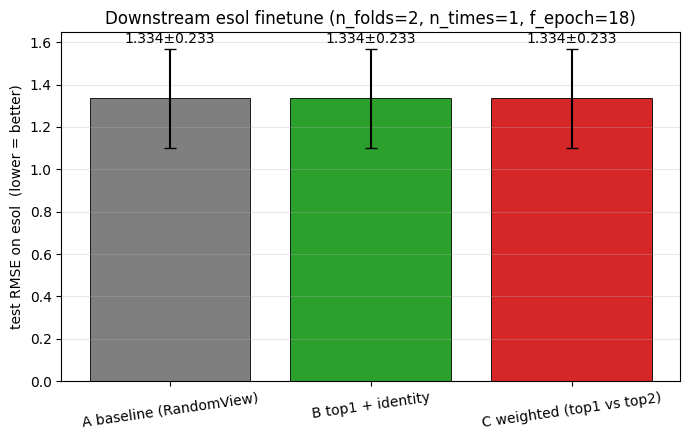

In [11]:
# --- 8. RMSE bar chart -----------------------------------------------------
fig, ax = plt.subplots(figsize=(7.0, 4.5))
xs, ys, errs, txts, bar_colors = [], [], [], [], []
for side in SIDES:
    r = fine_results.get(side, {})
    m = r.get('rmse_mean')
    if m is None or np.isnan(m):
        continue
    xs.append(labels[side])
    ys.append(m)
    errs.append(r.get('rmse_sd') or 0.0)
    # 4 decimals: .3f bar labels made distinct runs look identical at 0.001 scale.
    txts.append(f"{m:.4f}±{r.get('rmse_sd', 0.0):.4f}")
    bar_colors.append(colors[side])
bars = ax.bar(xs, ys, yerr=errs, capsize=4,
              color=bar_colors,
              edgecolor='black', linewidth=0.6)
ax.set_ylabel(f'test RMSE on {DATASET}  (lower = better)')
ax.set_title(f'Downstream {DATASET} finetune (n_folds={N_FOLDS}, n_times={N_TIMES}, f_epoch={F_EPOCH})')
ax.grid(axis='y', alpha=0.3)
for bar, txt in zip(bars, txts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(errs or [0]) * 1.05 + 1e-3,
            txt, ha='center', va='bottom', fontsize=10)
for lbl in ax.get_xticklabels():
    lbl.set_rotation(8)
out = RUN_DIR / f'finetune_rmse_{FIG_TS}.png'
plt.tight_layout()
fig.savefig(out, dpi=140, bbox_inches='tight')
print('saved:', out)
plt.show()

In [12]:
# --- 9. Combined summary table ---------------------------------------------
import pandas as pd
rows = []
for side in SIDES:
    pr = pre_results.get(side, {})
    fr = fine_results.get(side, {})
    dr = dist_results.get(side, {})
    rows.append({
        'side': side,
        'label': labels[side],
        'view': ','.join(pr.get('view_classes', [])),
        'pretrain_wall_s': pr.get('wall_s'),
        'pretrain_last_loss': (pr.get('losses_per_epoch') or [None])[-1],
        'rmse_mean': fr.get('rmse_mean'),
        'rmse_sd': fr.get('rmse_sd'),
        'finetune_wall_s': fr.get('wall_s'),
        'slots_used': dr.get('n_slots_used'),
        'kl_to_uniform_bits': dr.get('kl_to_uniform_bits'),
        'per_graph_entropy_bits_mean': dr.get('per_graph_entropy_bits_mean'),
    })
df = pd.DataFrame(rows)
df.to_csv(RUN_DIR / 'summary.csv', index=False)
print('saved:', RUN_DIR / 'summary.csv')
df

saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0116/summary.csv


,side,label,view,pretrain_wall_s,pretrain_last_loss,rmse_mean,rmse_sd,finetune_wall_s,slots_used,kl_to_uniform_bits,per_graph_entropy_bits_mean
0,A,A baseline (RandomView),"RandomView,RandomView",8.920040,9.266991,1.334483,0.233403,14.931425,2,1.000016,9.602313e-01
1,B,B top1 + identity,"WeightedMMFFView,function",2.153428,9.266991,1.334483,0.233403,14.226951,4,0.107304,-1.442823e-12
2,C,C weighted (top1 vs top2),"WeightedMMFFView,WeightedMMFFView",2.271358,9.266991,1.334483,0.233403,14.129102,4,0.107304,-1.442823e-12


## 노트

1. **스모크 vs 본격**
   - 셀 1 에서 `QUALITY_SMOKE = True` 를 켜면 짧은 epoch/fold·SchNet·적은 `DIST_N_CALLS` 로 빠르게 통과 확인.
   - 수동 스모크: `P_EPOCH=2~5`, `F_EPOCH=10~20` 등. 본격 비교: `QUALITY_SMOKE = False` 후 `P_EPOCH=50~100`, `F_EPOCH=100`, `N_TIMES=3`.
2. **재현성**
   - 모든 셀이 `seed=2222` 사용. `MMFFRANDOM_FAST` / `MMFFRANDOM_WEIGHTED` 환경변수는 `pretrain_quality_core` 내부의 `_clean_aug_env()` 가 자동으로 마스킹.
   - 호스트 환경 변수는 셀 종료 후 원상복귀 (non-destructive).
3. **체크포인트**
   - `./models/quality_<MMDD_HHMM>/{A,B,C}/...` 에 각각 별도 저장. 같은 시간대에 여러 번 돌리면 폴더 이름의 분 단위 timestamp 가 달라지면서 자동 분리.
4. **`C` 가 `A` 보다 RMSE 가 낮지 않다면**
   - `WEIGHT_KT` 를 0.1~0.5 로 줄여 분포를 더 첨예하게.
   - `QDF_PROPERTY` 를 `atomization` 으로 (homolumo 는 conformer 간 spread 가 매우 작음).
   - `compute_mmff_weights.py` 메타데이터 (`meta['qdf_property']`, `meta['normalize']`) 가 의도대로인지 확인.
   - epoch 을 늘려서 학습 신호를 더 받게.

5. **Finetune 시간**
   - side 개수는 `SIDES` (기본 A/B/C 세 개). 시간은 대략 side 1개당 비용 × `len(SIDES)`.
   - 더 빠르게: `QUALITY_SMOKE`, 또는 `N_FOLDS=2` + `F_EPOCH=20`.
   - 더 정확하게 (느려짐): `N_TIMES=3` × `N_FOLDS=5` × `F_EPOCH=100`.
   - `FINETUNE_BATCH` 를 256/512 로 더 키워도 됨 (z_dim=32, SchNet 가벼움); ESOL 1128 분자라 batch=512 면 train_loader 가 fold 당 2 batch.

6. **B 측면**
   - **B (현재)**: `MMFFweighted_top1` + `aug_2=None` → 첫 뷰만 가중 argmax 슬롯, 둘째 뷰는 원본 좌표(identity). 예전 *fast random* B 와는 다른 ablation.
   - 속도/커널만 보려면 `compare_pretrain_ab.py` 를 사용.